# Odd - Even Analysis

Odd - Even analysis consists of separating a survey into odd- and even-numbered flight-lines, gridding each separately and then calculating the RMS difference between the two resultant grids.

We will use the 2012 Kauring gravimetry data in this notebook. If you haven't already, run the `Prepare_ASEGGDF2` notebook so that the survey data are ready for QC.

___

First, import the required modules, and set the path to the geowhizz file.

In [1]:
from pathlib import Path
import galileoQC  as qc

In [2]:
dh = Path(r'./Kauring_grv/GRAV.hdf5')

In [3]:
if not dh.exists():
    %run ./Prepare_2012KauringData.ipynb

___

We can use `reportLines` to see that the traverse and control lines have been correctly classified. But we have not classified on the basis of odd or even line-numbering yet.

In [4]:
qc.reportLines(dh)

0 even lines, 0 odd lines.
213 traverse lines, 11 control lines, 0 not classified.
0 planned lines, 224 unplanned lines, total 224.

 Whizz Version 1.0 

Odd Lines:
 [] 

Even Lines:
 [] 

Traverse Lines:
 ['100100', '100200', '100300', '100400', '100500', '100600', '100700', '100800', '100900', '101000', '101100', '101200', '101300', '101400', '101500', '101600', '101700', '101800', '101900', '102000', '102100', '102200', '102300', '102400', '102500', '102600', '102700', '102800', '102900', '103000', '103100', '103200', '103300', '103400', '103500', '103600', '103700', '103800', '103900', '104000', '104100', '104200', '104300', '104400', '104500', '104600', '104700', '104800', '104900', '105000', '105100', '105200', '105300', '105400', '105500', '105600', '105700', '105800', '105900', '106000', '106100', '106200', '106300', '106400', '106500', '106600', '106700', '106800', '106900', '107000', '107100', '107200', '107300', '107400', '107500', '107600', '107700', '107800', '107900', '10

___

Furthermore, the flight-line map shows that there are two distinct blocks in the file. We don't want the smaller block with closer line spacing and different line directions.

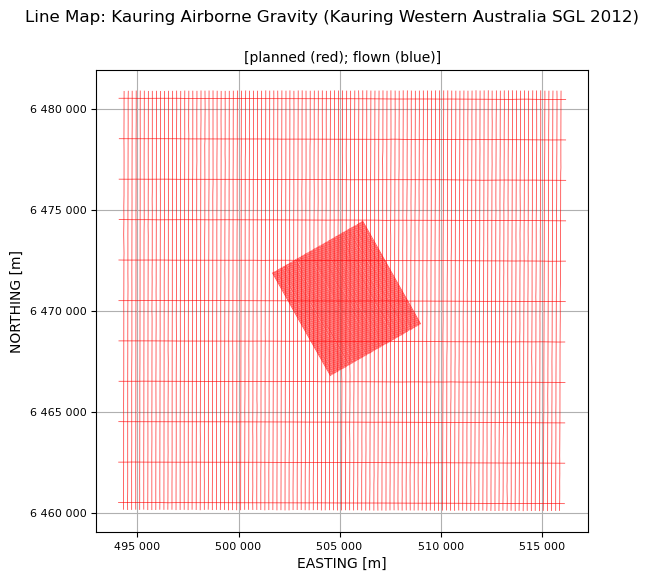

In [5]:
qc.linesMap([dh], whizzPlanFile=dh)

___

We want only the flight-lines whose line-number starts with a "1". First, we copy and paste them from the `qc.reportLines` output, making sure we capture all traverse and control lines that start with a "1", and no others.

In [6]:
gm_lines = ['100100', '100200', '100300', '100400', '100500', '100600', '100700', '100800', 
            '100900', '10100', '101000', '101100', '101200', '101300', '101400', '101500', 
            '101600', '101700', '101800', '101900', '10200', '102000', '102100', '102200', 
            '102300', '102400', '102500', '102600', '102700', '102800', '102900', '10300', 
            '103000', '103100', '103200', '103300', '103400', '103500', '103600', '103700', 
            '103800', '103900', '10400', '104000', '104100', '104200', '104300', '104400', 
            '104500', '104600', '104700', '104800', '104900', '10500', '105000', '105100', 
            '105200', '105300', '105400', '105500', '105600', '105700', '105800', '105900', 
            '10600', '106000', '106100', '106200', '106300', '106400', '106500', '106600', 
            '106700', '106800', '106900', '10700', '107000', '107100', '107200', '107300', 
            '107400', '107500', '107600', '107700', '107800', '107900', '10800', '108000', 
            '108100', '108200', '108300', '108400', '108500', '108600', '108700', '108800', 
            '108900', '10900', '109000', '109100', '109200', '109300', '109400', '109500', 
            '109600', '109700', '109800', '109900', '11000', '110000', '110100', '110200', 
            '110300', '110400', '110500', '110600', '110700', '110800', '110900', '11100']

___

The flight-line map shows that we have the ones we want.

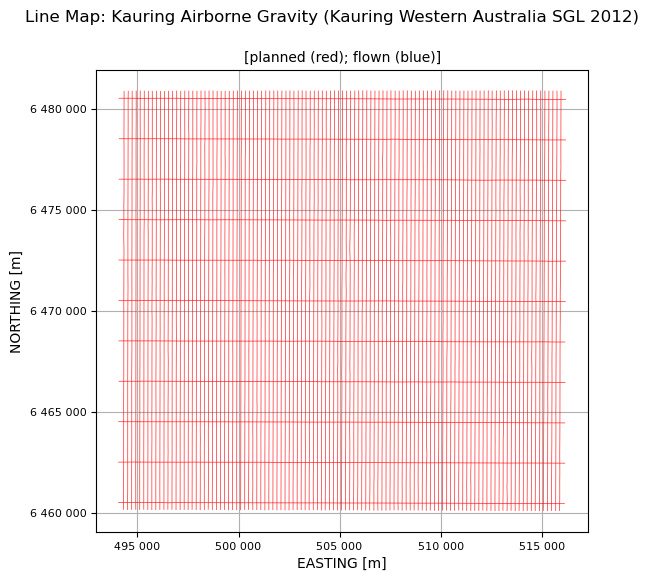

In [7]:
qc.linesMap([dh], whizzPlanFile=dh, planLines=gm_lines)

___

Now, we write a short script to sort them into odd and even numbered line-lists.

In [8]:
odd = []
even = []
for line in gm_lines:
    num = int(float(line)/100)
    if num % 2 == 0:
        even.append(line)# Even 
    else:
        odd.append(line) # Odd

 ... and we update the survey meta-data with these lists, and report the lines so we can check we have what we want. (`updateOddOrEven` ignore control lines for assigning parity.)

In [9]:
qc.updateOddOrEven(whizzFile=dh, oddlines=odd, evenlines=even, planFile='', verbose=False)
qc.reportLines(dh)

54 even lines, 55 odd lines.
213 traverse lines, 11 control lines, 0 not classified.
0 planned lines, 224 unplanned lines, total 224.

 Whizz Version 1.0 

Odd Lines:
 ['100100', '100300', '100500', '100700', '100900', '101100', '101300', '101500', '101700', '101900', '102100', '102300', '102500', '102700', '102900', '103100', '103300', '103500', '103700', '103900', '104100', '104300', '104500', '104700', '104900', '105100', '105300', '105500', '105700', '105900', '106100', '106300', '106500', '106700', '106900', '107100', '107300', '107500', '107700', '107900', '108100', '108300', '108500', '108700', '108900', '109100', '109300', '109500', '109700', '109900', '110100', '110300', '110500', '110700', '110900'] 

Even Lines:
 ['100200', '100400', '100600', '100800', '101000', '101200', '101400', '101600', '101800', '102000', '102200', '102400', '102600', '102800', '103000', '103200', '103400', '103600', '103800', '104000', '104200', '104400', '104600', '104800', '105000', '105200', '1054

___

Now we can perform the odd-even analysis. The default gridding parameters have been accepted here so the grid is not great. However, the RMS difference between odd and even numbered lines is $0.57\,mGal$ which is a good result.

54 even lines, 55 odd lines.
54 lines; total number of fids in whizz file = 47038.
    GRVBGL100S_267: min = -42.3, max = -18.6, mean = -30.

55 lines; total number of fids in whizz file = 47875.
    GRVBGL100S_267: min = -42, max = -18.9, mean = -30.

Processing (x, y, z) = (EASTING, NORTHING, GRVBGL100S_267). GRVBGL100S_267 in mGal.
Processing (x, y, z) = (EASTING, NORTHING, GRVBGL100S_267). GRVBGL100S_267 in mGal.


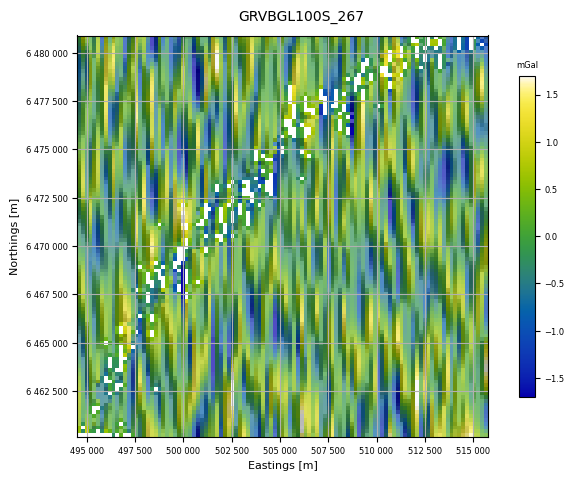

RMS of result = 0.57 mGal
mean of result = 0.00 mGal
min of result = -2.09 mGal
max of result = 2.14 mGal
Array shape = (105, 107)


In [10]:
qc.oddevenlines(dh, 'GRVBGL100S_267', 200.0)

___

Alternatively, you can always enter the lists of odd and even lines directly into the function call. This can be useful if, for example, you want to omit some lines from the analysis. Here is an example.

In [11]:
# First remove the control lines from the even and odd lines (`updateOddOrEven`
# does this automatically for us in the previous example):
controls = ['10100', '10200', '10300', '10400', '10500', '10600', '10700',
            '10800', '10900', '11000', '11100']
new_even = even.copy()
new_odd = odd.copy()
for ctrl in controls:
    if ctrl in new_even:
        new_even.remove(ctrl)
    if ctrl in new_odd:
        new_odd.remove(ctrl)

53 lines; total number of fids in whizz file = 46169.
    GRVBGL100S_267: min = -42.3, max = -18.6, mean = -30.2.

55 lines; total number of fids in whizz file = 47875.
    GRVBGL100S_267: min = -42, max = -18.9, mean = -30.

Processing (x, y, z) = (EASTING, NORTHING, GRVBGL100S_267). GRVBGL100S_267 in mGal.
Processing (x, y, z) = (EASTING, NORTHING, GRVBGL100S_267). GRVBGL100S_267 in mGal.


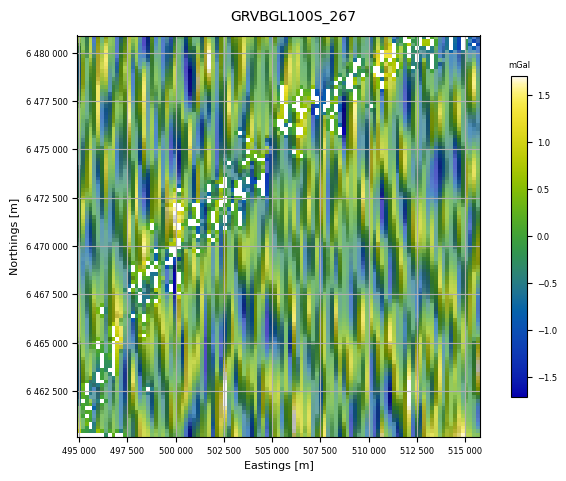

RMS of result = 0.57 mGal
mean of result = -0.00 mGal
min of result = -2.09 mGal
max of result = 2.14 mGal
Array shape = (105, 105)


In [12]:
# Now remove the "unwanted" first even line:
modified_even = new_even.pop(0)
qc.oddevenlines(dh, 'GRVBGL100S_267', 200.0, oddlines=new_odd, evenlines=new_even)